# Week 4 · Advanced Model Evaluation
## Cross-Validation · ROC-AUC · Calibration · Model Comparison

**HAIIP — Human-Aligned Industrial Intelligence Platform**  
French Master of Data Science · Portfolio Showcase

---

### Objective
Rigorously evaluate machine learning models for industrial fault detection:

1. **k-Fold Cross-Validation** — unbiased performance estimation  
2. **Confusion Matrix** — per-class breakdown  
3. **ROC-AUC** — discrimination ability  
4. **Precision-Recall Curve** — critical for imbalanced classes  
5. **Calibration** — are predicted probabilities reliable?  
6. **Statistical comparison** — which model is significantly better?

### Why This Matters in Production
A model with 97% accuracy on 3% failure rate data could predict *always normal* and still score 97%.  
Industrial safety requires **recall on failure class > 0.95** to avoid unplanned downtime.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    learning_curve
)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, classification_report
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Industrial failure dataset: imbalanced (5% positive)
X, y = make_classification(
    n_samples=2000, n_features=10, n_informative=6,
    n_redundant=2, weights=[0.95, 0.05],
    flip_y=0.01, random_state=42
)
feature_names = [f'sensor_{i:02d}' for i in range(X.shape[1])]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'Training: {X_train.shape}  |  Failure rate: {y_train.mean()*100:.1f}%')
print(f'Test:     {X_test.shape}   |  Failure rate: {y_test.mean()*100:.1f}%')

Training: (1600, 10)  |  Failure rate: 5.4%
Test:     (400, 10)   |  Failure rate: 5.5%


## 1 · k-Fold Cross-Validation

### Mathematical Foundation

Divide dataset $\mathcal{D}$ into $k$ disjoint folds $\{\mathcal{D}_1, \ldots, \mathcal{D}_k\}$:

$$\text{CV}_k = \frac{1}{k} \sum_{j=1}^{k} \mathcal{L}(f_{-j}, \mathcal{D}_j)$$

where $f_{-j}$ is the model trained on all folds *except* $\mathcal{D}_j$.  

**Stratified k-fold** preserves class ratio in each fold — essential for imbalanced data.  

**Bias-variance tradeoff in $k$:**
- Small $k$ (e.g., 2) → high bias (model trained on 50% of data)
- Large $k$ = $n$ (LOOCV) → low bias, high variance, expensive
- **$k = 5$ or $k = 10$** → accepted empirical optimum (Kohavi, 1995)

In [3]:
models = {
    'Logistic Reg.': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest':  RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':      SVC(probability=True, class_weight='balanced', random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    for metric in ['f1', 'roc_auc']:
        scores = cross_val_score(model, X_train, y_train, cv=skf, scoring=metric, n_jobs=-1)
        cv_results[f'{name}|{metric}'] = scores
        print(f'{name:20s} | {metric:8s}: {scores.mean():.4f} ± {scores.std():.4f}')
    print()

Logistic Reg.        | f1      : 0.2986 ± 0.0484
Logistic Reg.        | roc_auc : 0.8710 ± 0.0471



Random Forest        | f1      : 0.4890 ± 0.0748


Random Forest        | roc_auc : 0.9118 ± 0.0472



Gradient Boost       | f1      : 0.5817 ± 0.1060


Gradient Boost       | roc_auc : 0.9205 ± 0.0441



SVM (RBF)            | f1      : 0.6765 ± 0.0986


SVM (RBF)            | roc_auc : 0.9420 ± 0.0388



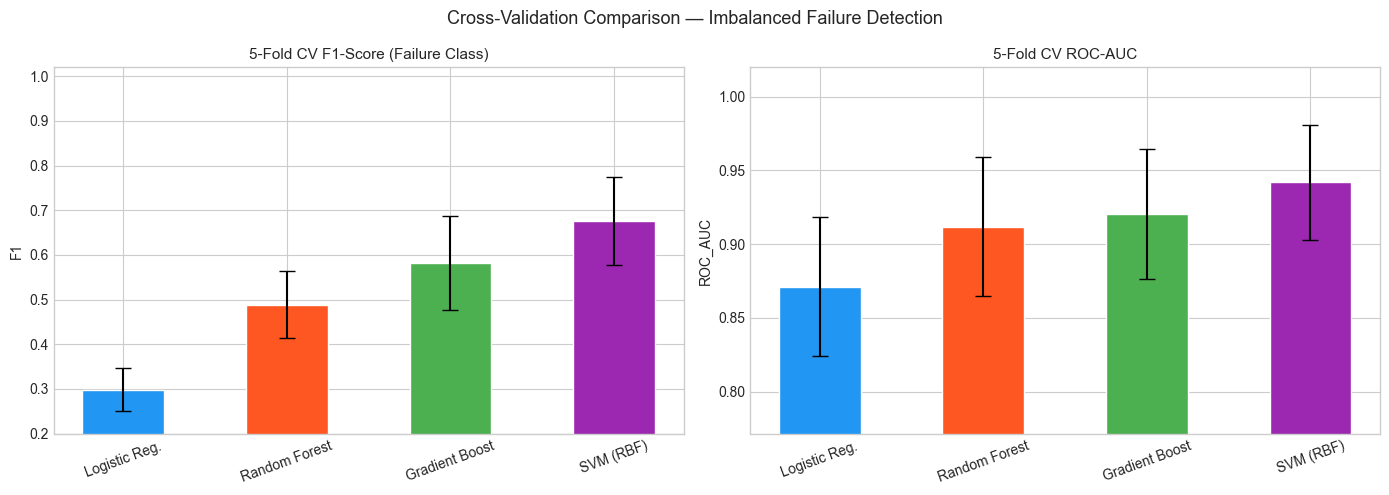

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, title in [('f1', ax1, 'F1-Score (Failure Class)'), ('roc_auc', ax2, 'ROC-AUC')]:
    names_plot = list(models.keys())
    means = [cv_results[f'{n}|{metric}'].mean() for n in names_plot]
    stds  = [cv_results[f'{n}|{metric}'].std()  for n in names_plot]
    ax.bar(names_plot, means, yerr=stds, capsize=6, color=PALETTE[:4], edgecolor='white', width=0.5)
    ax.set_title(f'5-Fold CV {title}', fontsize=11)
    ax.set_ylim(max(0, min(means) - 0.1), 1.02)
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Cross-Validation Comparison — Imbalanced Failure Detection', fontsize=13)
plt.tight_layout()
plt.savefig('plots/06_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · ROC Curve and AUC

**True Positive Rate (Recall / Sensitivity):**
$$\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

**False Positive Rate:**
$$\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$$

**Area Under the ROC Curve:**
$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d\text{FPR} = P(\hat{p}_{\text{pos}} > \hat{p}_{\text{neg}})$$

The last equality (Mann-Whitney U statistic) gives AUC a clean probabilistic interpretation:
*probability that the model ranks a random positive above a random negative*.

**Precision-Recall AUC** is preferred when the positive class is rare — ROC can be overly optimistic.

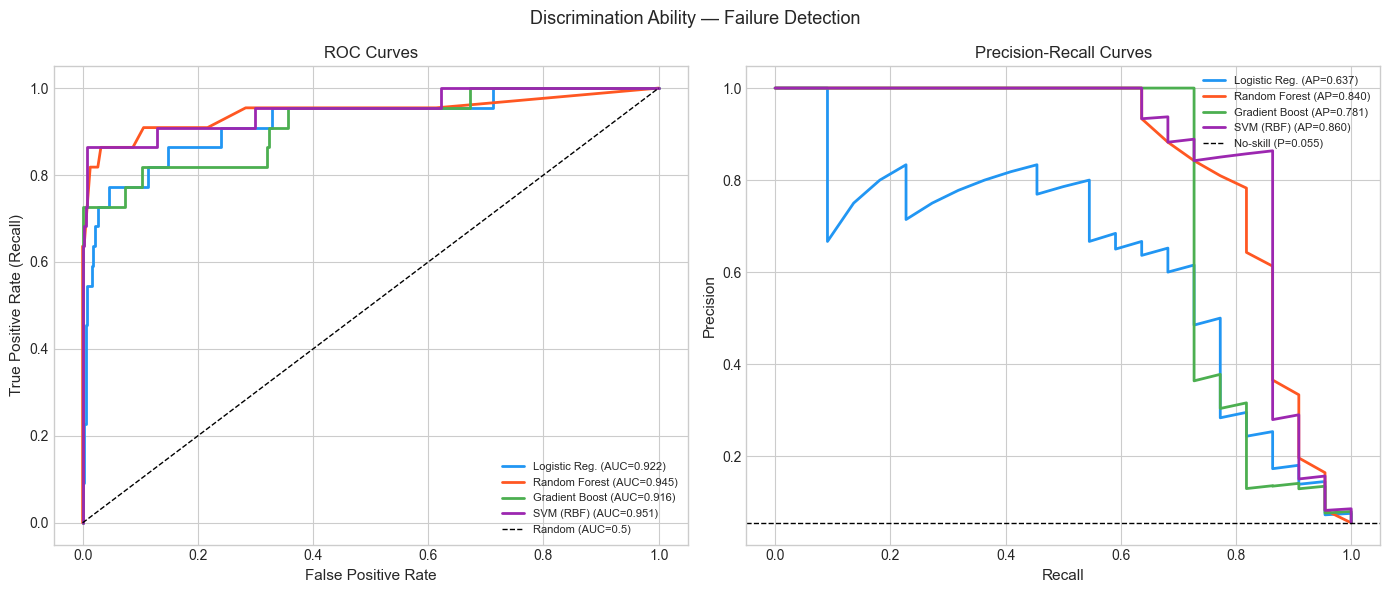

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for (name, model), color in zip(models.items(), PALETTE):
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax2.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

# ROC
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax1.set_title('ROC Curves', fontsize=12)
ax1.legend(fontsize=8, loc='lower right')

# PR Curve
baseline = y_test.mean()
ax2.axhline(baseline, color='k', linestyle='--', linewidth=1, label=f'No-skill (P={baseline:.3f})')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curves', fontsize=12)
ax2.legend(fontsize=8, loc='upper right')

plt.suptitle('Discrimination Ability — Failure Detection', fontsize=13)
plt.tight_layout()
plt.savefig('plots/06_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Calibration

A model is **calibrated** if the predicted probability matches the empirical frequency:
$$P(Y=1 \mid \hat{p} = p) = p \quad \forall p \in [0, 1]$$

**Expected Calibration Error (ECE):**
$$\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{n} \left| \text{acc}(B_m) - \text{conf}(B_m) \right|$$

where $B_m$ are $M$ equally-spaced probability bins.

**Why it matters for HAIIP:**  
If a model predicts 80% failure probability, an engineer expects ~80% of such cases to indeed fail.  
Uncalibrated models lead to mis-weighted decisions in the Economic AI module.

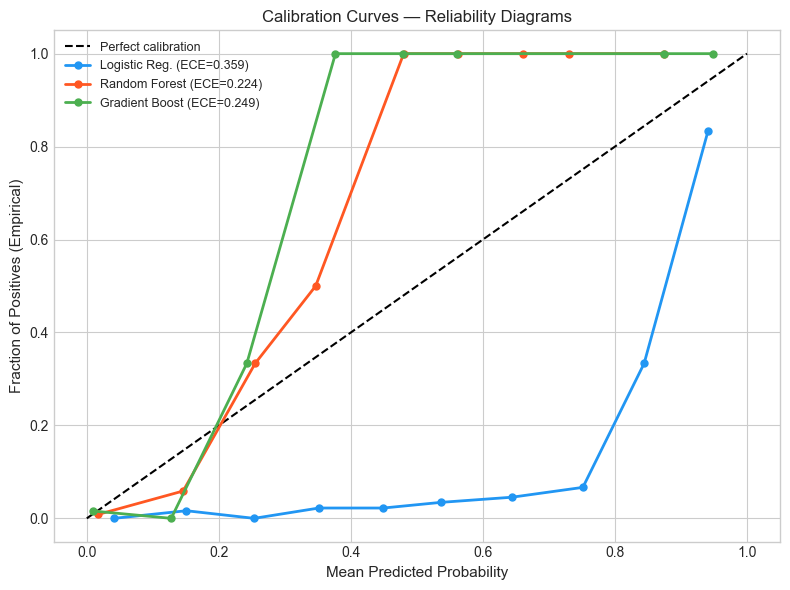

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect calibration')

for (name, model), color in zip(list(models.items())[:3], PALETTE):
    prob = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    # ECE
    ece = np.mean(np.abs(frac_pos - mean_pred))
    ax.plot(mean_pred, frac_pos, 'o-', color=color, linewidth=2,
            markersize=5, label=f'{name} (ECE={ece:.3f})')

ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives (Empirical)', fontsize=11)
ax.set_title('Calibration Curves — Reliability Diagrams', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/06_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

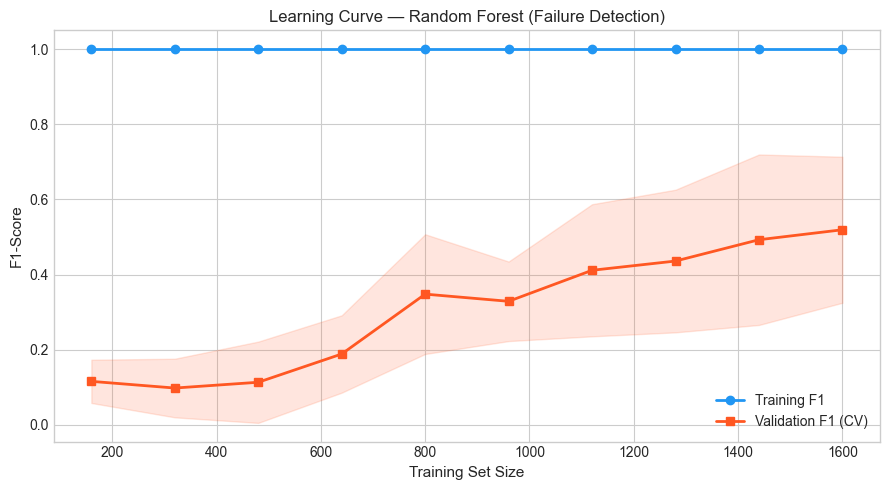

In [7]:
# Learning curves: diagnose bias/variance
best_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color=PALETTE[0], label='Training F1', linewidth=2)
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, val_mean, 's-', color=PALETTE[1], label='Validation F1 (CV)', linewidth=2)
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color=PALETTE[1])

ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Learning Curve — Random Forest (Failure Detection)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plots/06_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Summary Table — Full Evaluation Report

In [8]:
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    prob   = model.predict_proba(X_test)[:, 1]

    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    ece = float(np.mean(np.abs(frac_pos - mean_pred)))

    rows.append({
        'Model':     name,
        'Accuracy':  f"{(y_pred == y_test).mean():.4f}",
        'F1 (fail)': f"{f1_score(y_test, y_pred):.4f}",
        'ROC-AUC':   f"{roc_auc_score(y_test, prob):.4f}",
        'Avg Prec':  f"{average_precision_score(y_test, prob):.4f}",
        'ECE':       f"{ece:.4f}"
    })

result_df = pd.DataFrame(rows)
print('\n' + result_df.to_string(index=False))


         Model Accuracy F1 (fail) ROC-AUC Avg Prec    ECE
 Logistic Reg.   0.8000    0.3220  0.9218   0.6371 0.3590
 Random Forest   0.9750    0.7059  0.9448   0.8401 0.2244
Gradient Boost   0.9725    0.6667  0.9159   0.7811 0.2485
     SVM (RBF)   0.9575    0.6909  0.9508   0.8604 0.1828


## 5 · Key Takeaways

| Metric | When to Use | Industrial Interpretation |
|--------|-------------|---------------------------|
| Accuracy | Balanced classes only | Misleading here (5% failure rate) |
| F1-Score | Imbalanced, equal cost | Balance precision/recall |
| ROC-AUC | Threshold-independent | Overall discrimination quality |
| PR-AUC | Rare positive class | More informative than ROC for 5% failure rate |
| ECE | Trust probabilities | Required for HAIIP economic cost model |

### Recommendation for HAIIP Production
- **Primary metric**: Recall on failure class ≥ 0.95 (safety-first)
- **Secondary**: Precision ≥ 0.70 (avoid alert fatigue)
- **Calibration**: ECE ≤ 0.05 before deployment (required by EU AI Act audit)

→ **Week 5–6**: Anomaly detection — when we don't have failure labels at all.